# Data Exploration and Visualization

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 

# Set Pandas to display floats as whole numbers
pd.options.display.float_format = '{:,.0f}'.format

# Load the dataset
df = pd.read_excel('CarsDataset.xlsx')
df.columns


Index(['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity',
       'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices',
       'Fuel Types', 'Seats', 'Torque'],
      dtype='object')

# Data Cleaning Function

In [ ]:
def extract_first_number(x):
    nums = re.findall(r'\d+', str(x))
    for n in nums:
        n_clean = n.replace(',', ''). replace(' ', '')
        if n_clean and n_clean != '.':
            try:
                return float(n_clean)
            except:
                continue
    return np.nan

def extract_average_range_safe(x):
    nums = [n for n in re.findall(r"[\d,.]+", str(x)) if n.replace(',', '').replace('.', '').strip() != ""]
    try:
        if len(nums) == 2:
            v1 = float(nums[0].replace(',', '').replace(' ', ''))
            v2 = float(nums[1].replace(',', '').replace(' ', ''))
            return (v1 + v2) / 2
        elif len(nums) == 1:
            return float(nums[0].replace(',', '').replace(' ', ''))
        else:
            return np.nan
    except:
        return np.nan

def extract_price(x):
    x = str(x).replace('$', '').replace(',', '').strip()
    if '-' in x:
        parts = x.split('-')
        try:
            prices = [float(p) for p in parts if p.strip() != '']
            return np.mean(prices)
        except:
            return np.nan
    try:
        return float(x)
    except:
        return np.nan

In [ ]:
# Extract only numeric values from the relevant columns
df_clean = df.copy()
df_clean['Engine_CC']      = df_clean['CC/Battery Capacity'].apply(extract_first_number)
df_clean['HorsePower']     = df_clean['HorsePower'].apply(extract_average_range_safe)
df_clean['Max_Speed_kmh']  = df_clean['Total Speed'].apply(extract_first_number)
df_clean['Zero_100_Sec']   = df_clean['Performance(0 - 100 )KM/H'].apply(extract_first_number)
df_clean['Price_USD']      = df_clean['Cars Prices'].apply(extract_average_range_safe)
df_clean['Seats']          = df_clean['Seats'].apply(extract_first_number)
df_clean['Torque_Nm']      = df_clean['Torque'].apply(extract_average_range_safe) 

# Analysis

In [19]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nTop Brands:")
print(df['Company Names'].value_counts().head(10).to_string())
print("\nTop Fuel Types:")
print(df['Fuel Types'].value_counts().to_string())
print("\nSummary statistics for main numeric features:")
display(df_clean[['Engine_CC', 'HorsePower', 'Max_Speed_kmh', 'Zero_100_Sec', 'Seats', 'Torque_Nm', 'Price_USD']].describe()) 

Rows: 1218, Columns: 11

Top Brands:
Company Names
Nissan        149
Volkswagen    109
Porsche        96
Mazda          87
Mitsubishi     60
GMC            59
Chevrolet      58
Peugeot        54
Kia            54
Ford           54

Top Fuel Types:
Fuel Types
Petrol                     871
Diesel                     106
Electric                    97
Hybrid                      79
Petrol/Diesel               16
Petrol/Hybrid               16
Plug-in Hybrid               5
Hybrid (Petrol)              4
Diesel/Petrol                4
Petrol, Diesel               3
Hydrogen                     3
Petrol, Hybrid               2
Petrol/AWD                   2
plug in hyrbrid              1
Hybrid/Electric              1
Petrol/EV                    1
CNG/Petrol                   1
Hybrid/Petrol                1
Diesel Hybrid                1
Petrol (Hybrid)              1
Hybrid (Gas + Electric)      1
Gas / Hybrid                 1
Hybrid / Plug-in             1

Summary statistics for main

,Engine_CC,HorsePower,Max_Speed_kmh,Zero_100_Sec,Seats,Torque_Nm,Price_USD
count,"1,214","1,217","1,218","1,212","1,218","1,217","1,217"
mean,"1,414",306,216,7,5,507,"138,037"
std,"2,023",214,53,3,2,"1,050","711,042"
min,1,26,80,1,1,45,"4,000"
25%,2,153,180,5,4,250,"28,000"
50%,84,255,200,7,5,370,"42,500"
75%,"2,000",400,250,9,5,560,"70,000"
max,"16,100","1,850",500,35,20,"15,590","18,000,000"


Coefficients: [ 1.74334969e-02  1.54646264e+00 -1.63094152e+01 -5.33105696e+00
  5.83848644e-02  7.80337616e-05]
Intercept: 47.818443392473796
RMSE: 100.11655029676416
rsquared: 0.7806703863200573


Text(0.5, 1.0, 'Root Mean Squared Error (RMSE) \n100.11655029676416\n R-squared: 0.7806703863200573')

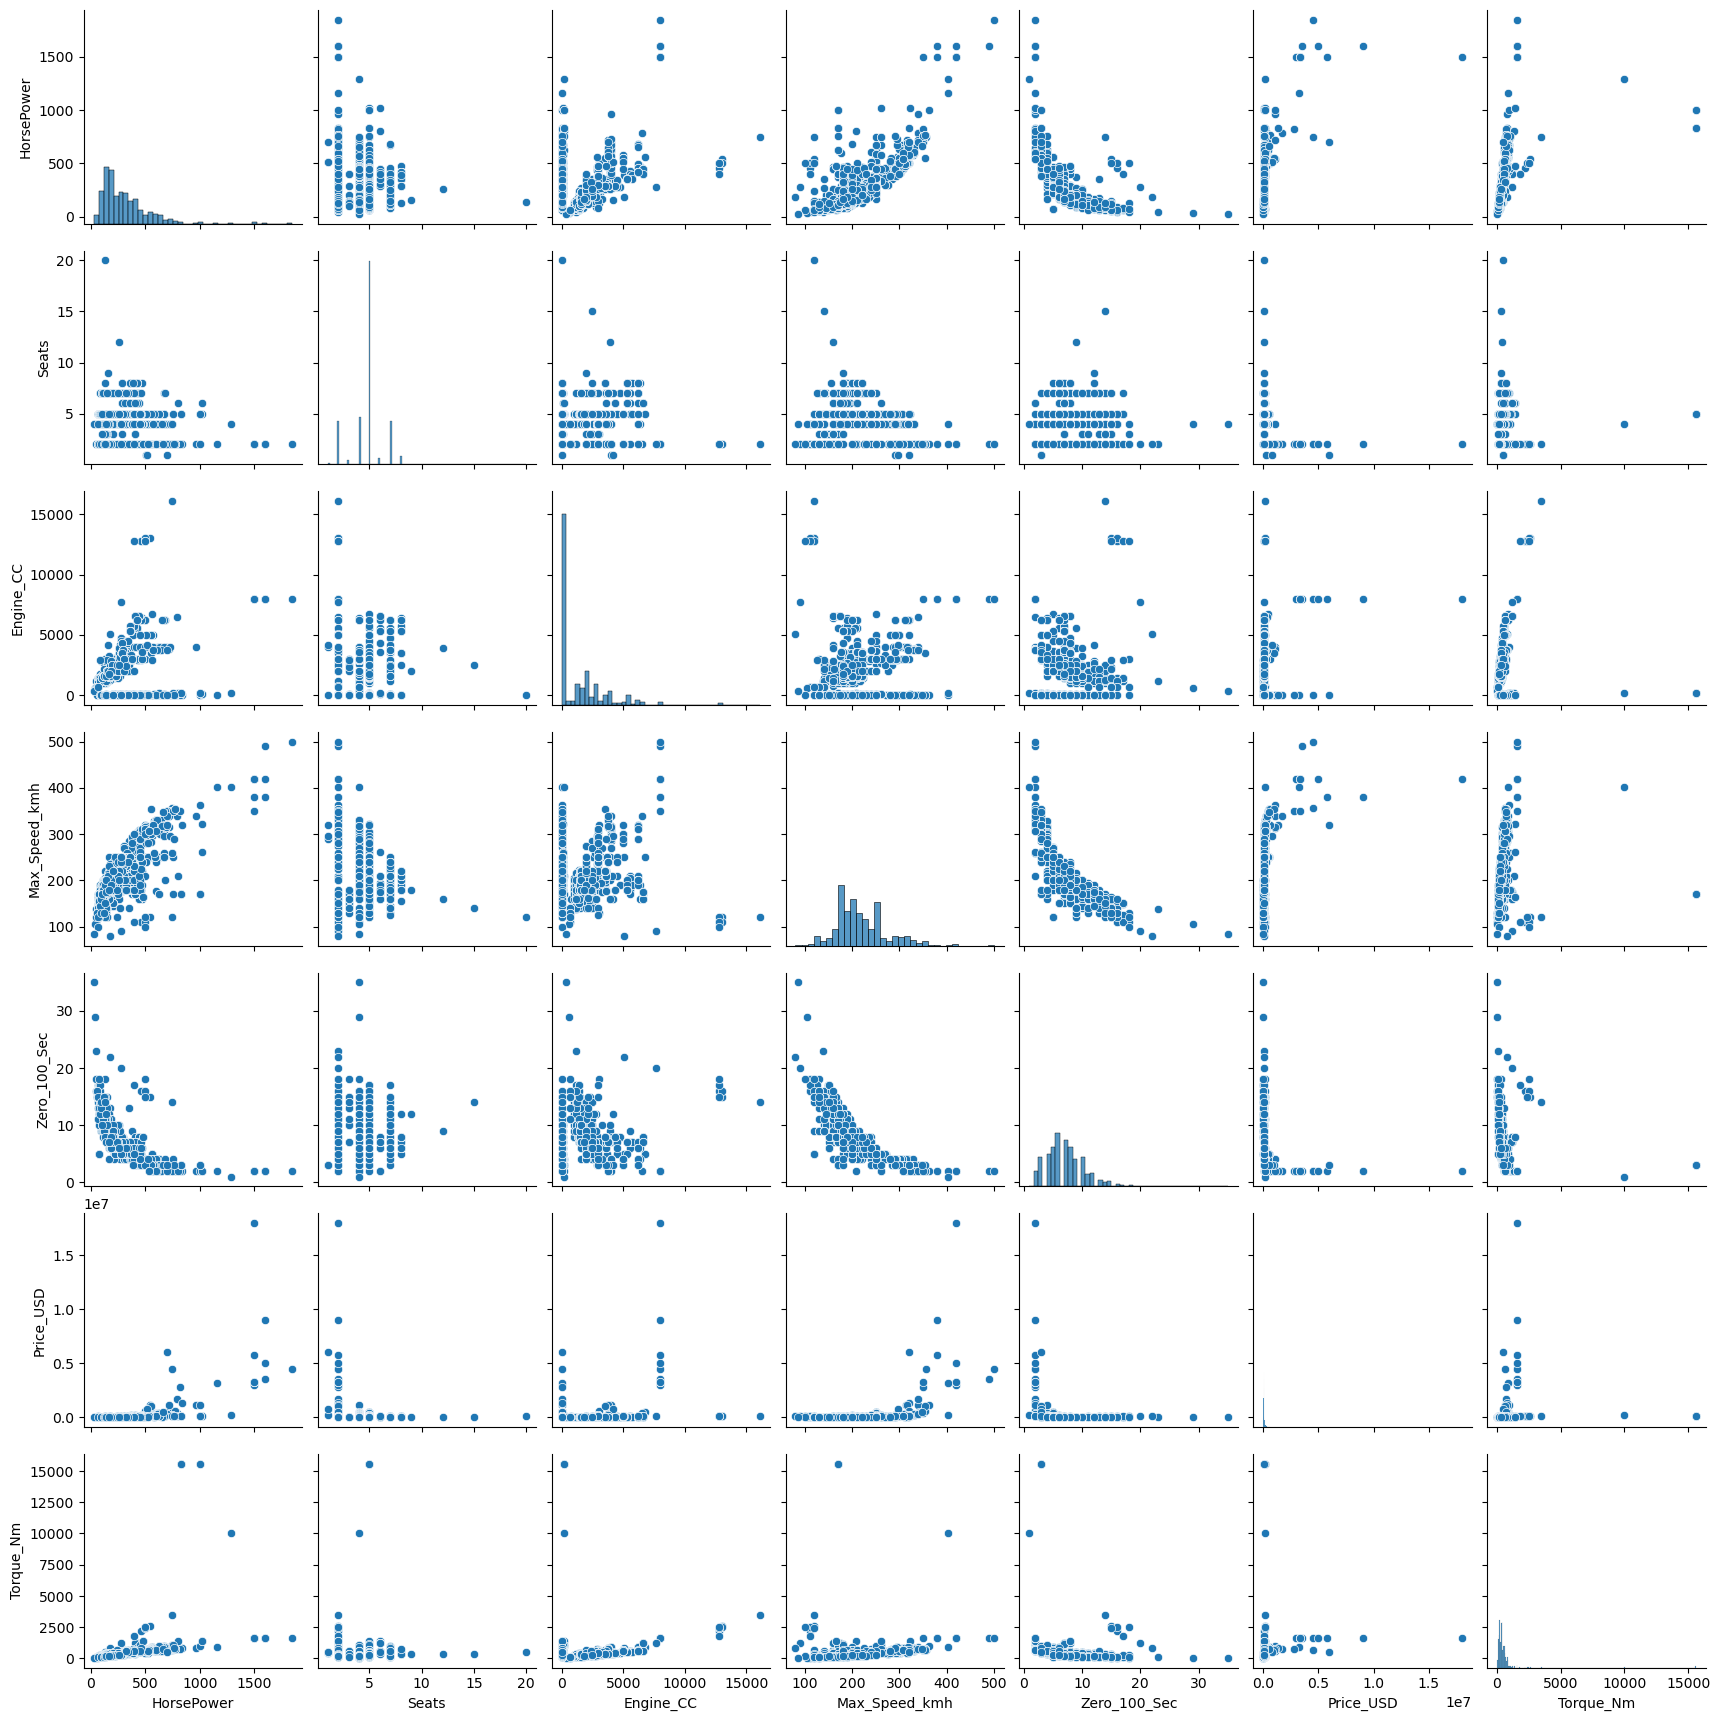

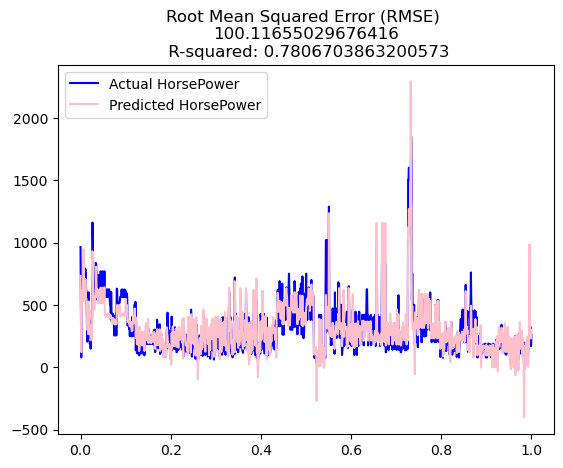

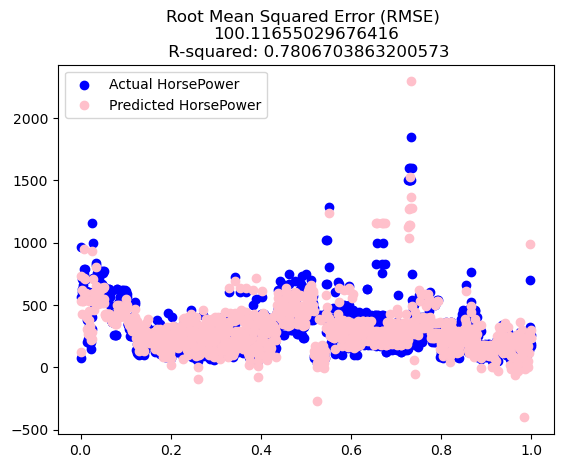

In [21]:
sns.pairplot(df_clean.select_dtypes(include=[np.number]))

X = df_clean[['Engine_CC', 'Max_Speed_kmh', 'Zero_100_Sec', 'Seats', 'Torque_Nm', 'Price_USD']]
y = df_clean['HorsePower']

# Drop rows with NaN in X or y
Xy = pd.concat([X, y], axis=1).dropna()
X_clean = Xy[X.columns]
y_clean = Xy['HorsePower']

lrModel = LinearRegression()
lrModel.fit(X_clean, y_clean)
print("Coefficients:", lrModel.coef_)
print("Intercept:", lrModel.intercept_)

predictedHorsePower = lrModel.predict(X_clean)

# Mean Squared Error
MSE = np.square(np.subtract(y_clean, predictedHorsePower)).mean()
RMSE = np.sqrt(MSE)

# R-squared is between 0 and 1, where 1 is a perfect fit
rsquared = r2_score(y_clean, predictedHorsePower)
print('RMSE:', RMSE)
print('rsquared:', rsquared)

# Line Plot 
plt.figure()
X_axis_points = np.linspace(0, 1, len(y_clean)) # Sample n_points
plt.plot(X_axis_points, y_clean, label='Actual HorsePower', color='blue')
plt.plot(X_axis_points, predictedHorsePower, label='Predicted HorsePower', color='pink')
plt.legend()
plt.title('Root Mean Squared Error (RMSE) \n' + str(RMSE) + '\n R-squared: ' + str(rsquared))

# Scatter Plot
plt.figure()
plt.scatter(X_axis_points, y_clean, label='Actual HorsePower', color='blue')
plt.scatter(X_axis_points, predictedHorsePower, label='Predicted HorsePower', color='pink')
plt.legend()
plt.title('Root Mean Squared Error (RMSE) \n' + str(RMSE) + '\n R-squared: ' + str(rsquared))


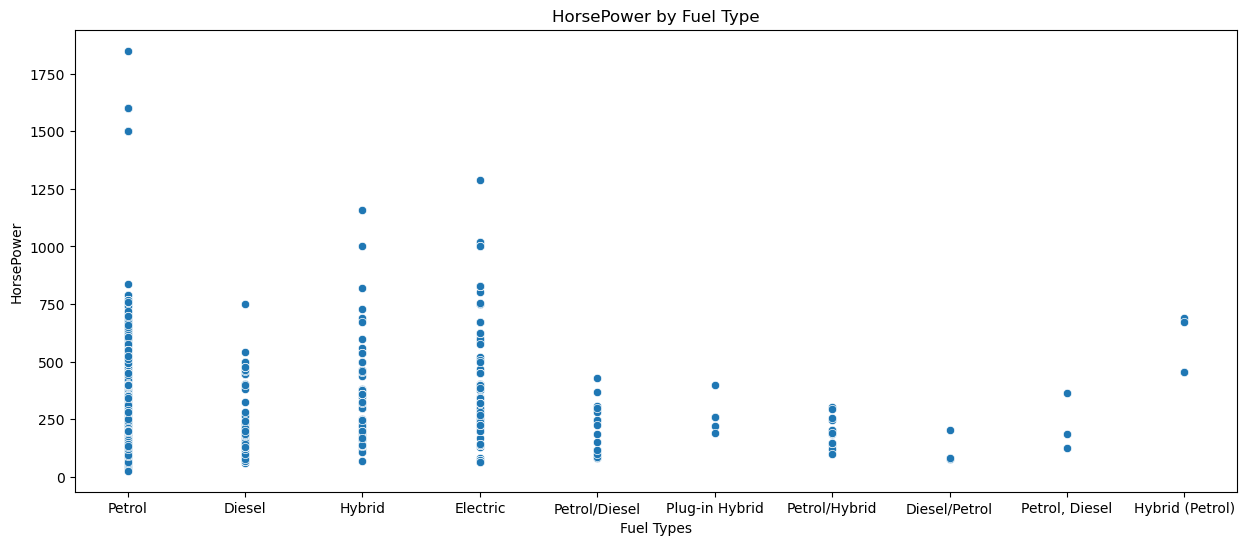

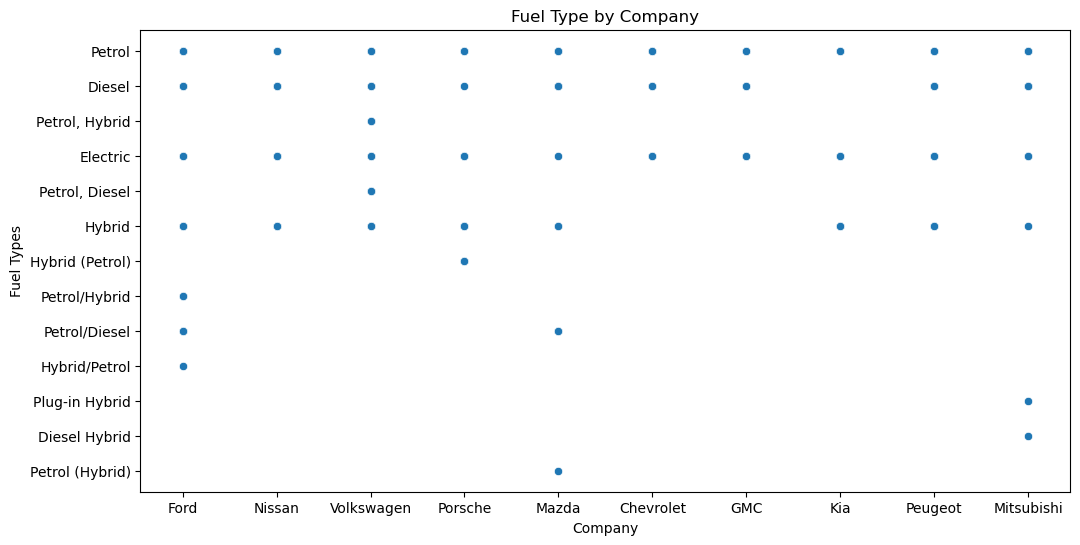

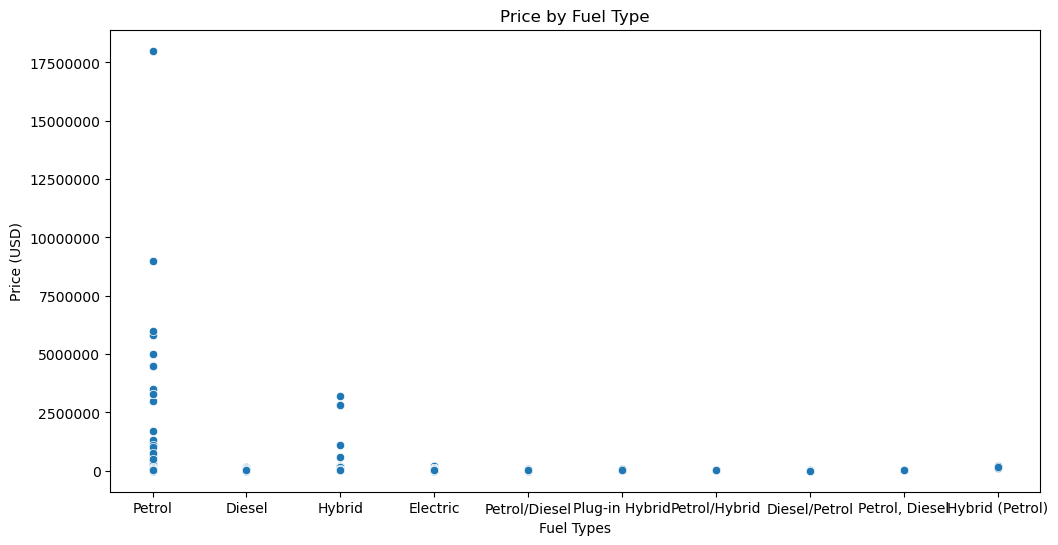

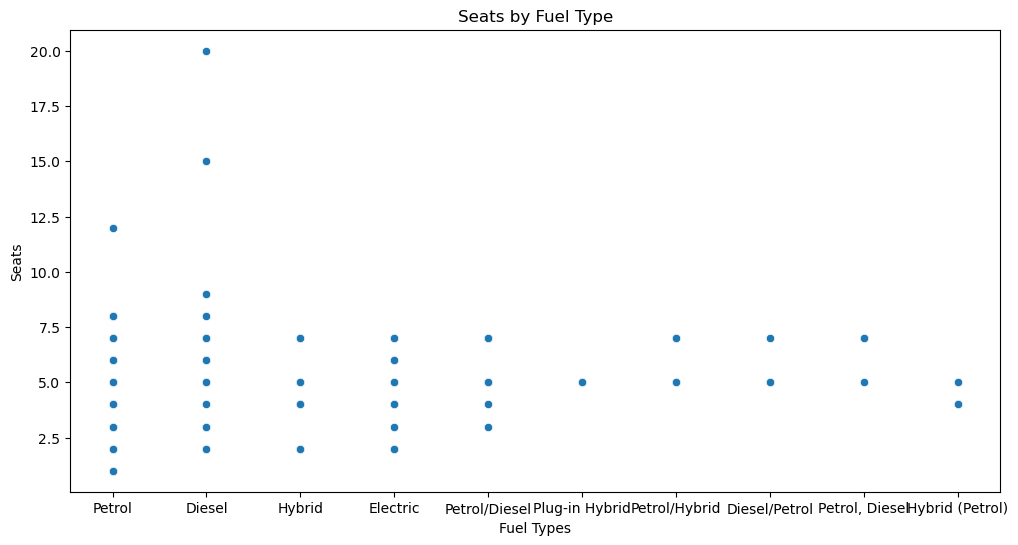

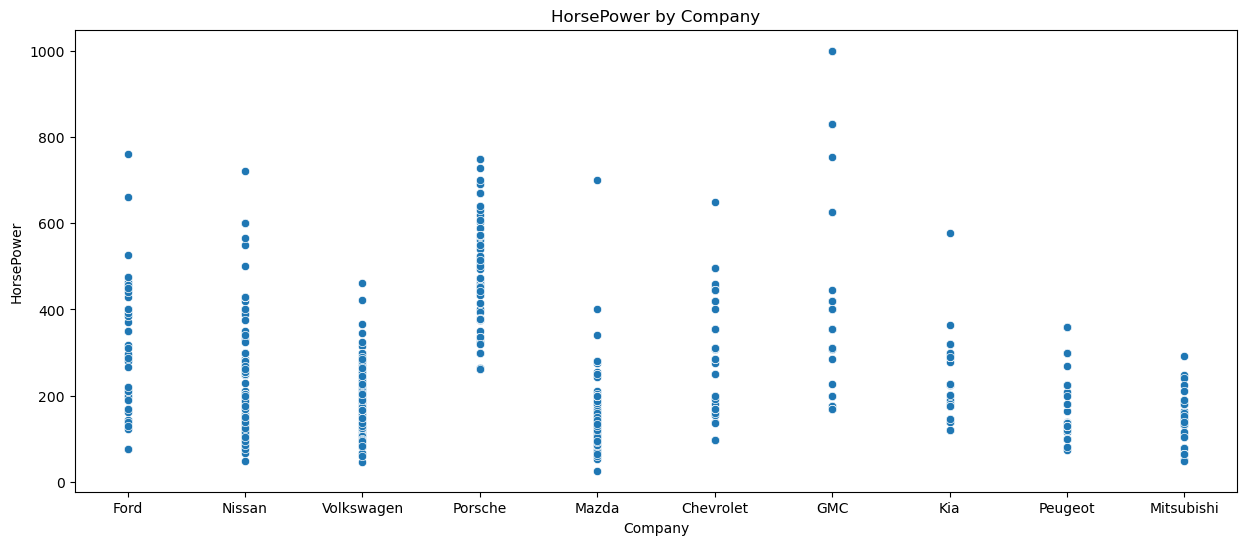

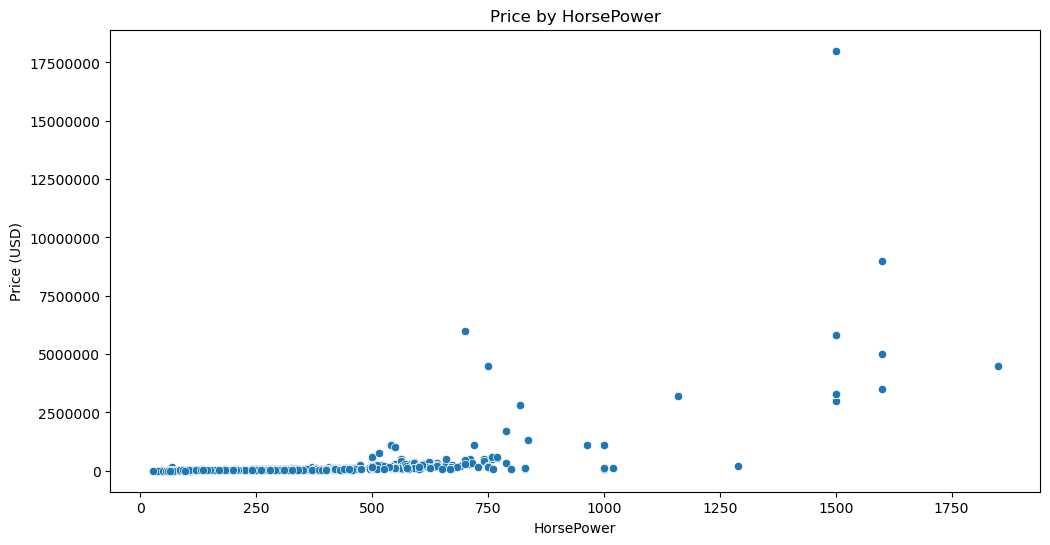

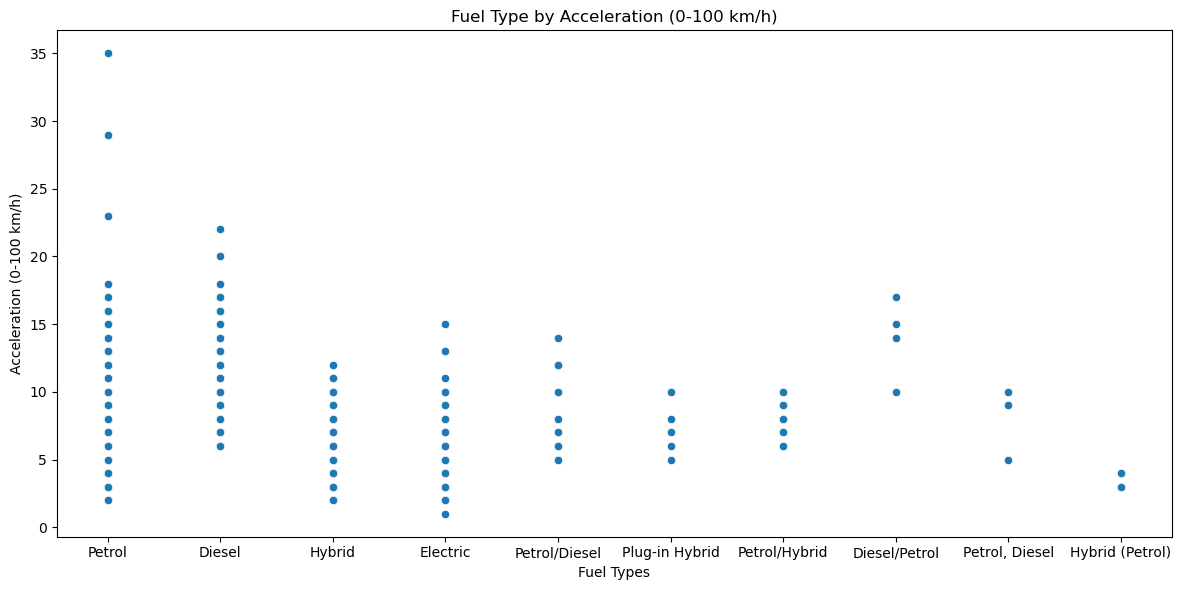

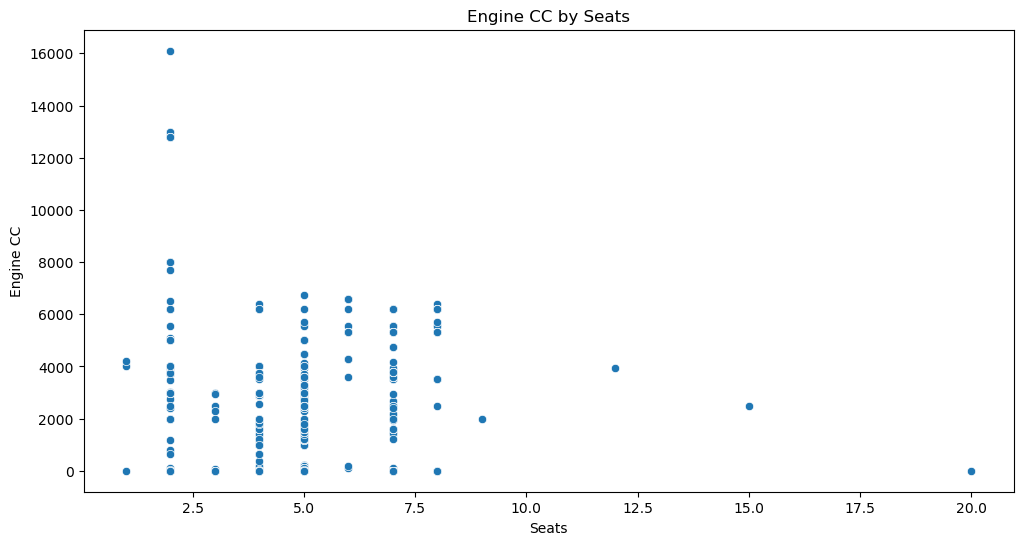

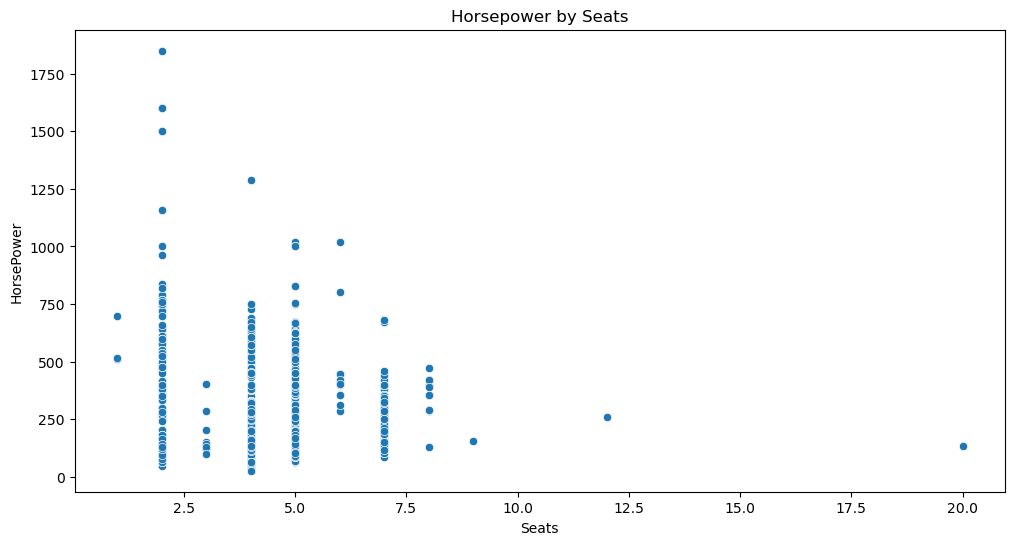

In [ ]:
# HorsePower by Fuel Type
top_fuel_types = df_clean['Fuel Types'].value_counts().head(10).index
plt.figure(figsize=(15, 6))
sns.scatterplot(x='Fuel Types', y='HorsePower', data=df_clean[df_clean['Fuel Types'].isin(top_fuel_types)])
plt.title('HorsePower by Fuel Type')
plt.xlabel('Fuel Types')
plt.ylabel('HorsePower')
plt.show()

# Fuel Type by Company
top_companies = df_clean['Company Names'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Company Names', y='Fuel Types', data=df_clean[df_clean['Company Names'].isin(top_companies)])
plt.title('Fuel Type by Company')
plt.xlabel('Company')
plt.ylabel('Fuel Types')
plt.show()

# Price by Fuel Type
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Fuel Types', y='Price_USD', data=df_clean[df_clean['Fuel Types'].isin(top_fuel_types)])
plt.title('Price by Fuel Type')
plt.xlabel('Fuel Types')
plt.ylabel('Price (USD)')
plt.ticklabel_format(style='plain', axis='y')  # Prevent scientific notation
plt.show()

# Seats by Fuel Type
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Fuel Types', y='Seats', data=df_clean[df_clean['Fuel Types'].isin(top_fuel_types)])
plt.title('Seats by Fuel Type')
plt.xlabel('Fuel Types')
plt.ylabel('Seats') 
plt.show()

# HorsePower by Company
plt.figure(figsize=(15, 6))
sns.scatterplot(x='Company Names', y='HorsePower', data=df_clean[df_clean['Company Names'].isin(top_companies)])
plt.title('HorsePower by Company')
plt.xlabel('Company')
plt.ylabel('HorsePower')
plt.show()

# Price by HorsePower
plt.figure(figsize=(12, 6))
sns.scatterplot(x='HorsePower', y='Price_USD', data=df_clean)
plt.title('Price by HorsePower')
plt.xlabel('HorsePower')
plt.ylabel('Price (USD)')
plt.ticklabel_format(style='plain', axis='y')  # Prevent scientific notation
plt.show()

# Fuel Type by Acceleration
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Fuel Types', y='Zero_100_Sec', data=df_clean[df_clean['Fuel Types'].isin(top_fuel_types)])
plt.title('Fuel Type by Acceleration (0-100 km/h)')
plt.xlabel('Fuel Types')
plt.ylabel('Acceleration (0-100 km/h)')
plt.tight_layout()
plt.show()

# Engine CC by Seats
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Seats', y='Engine_CC', data=df_clean)
plt.title('Engine CC by Seats')
plt.xlabel('Seats')
plt.ylabel('Engine CC')
plt.show()

# Horsepower by Seats
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Seats', y='HorsePower', data=df_clean)
plt.title('Horsepower by Seats')
plt.xlabel('Seats')
plt.ylabel('HorsePower')
plt.show()